---
## Scetion 0: Initial setup

**Imports**

In [1]:
# Imports
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt

# Importing macrocircuits also registers the `swim` and `swim_12_links` tasks with
# the dm_control swimmer suite, which is what lets suite.load() find them below.
from macrocircuits import ensure_tonic

# Clone neuromatch/tonic next to this notebook (once) and put it on the import path.
# It has to run before the tonic-backed imports below (training, models); see
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
ensure_tonic()

# The Swim task rewards swimming forward at _SWIM_SPEED and hides the target the
# stock dm_control swimmer chases. run_config/run_path turn the parameters chosen
# in Section 1 into the code strings train() needs and the paths it writes.
from macrocircuits.training import play_model, run_config, run_path, train  # See src/macrocircuits/training.py.
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    plot_performance,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## Scetion 1: Select parameters

**Parameters**

Everything you might want to vary lives here, so the training and plotting cells
below never have to be edited:

- `NETWORKS` — which architectures to train and compare (`'ncap'`, `'mlp'`).
- `N_LINKS` — swimmer body length (`6` → 5 joints, `12` → 11 joints).
- `RL_METHOD` — reinforcement-learning algorithm: `'ppo'`, `'a2c'` or `'trpo'`.
- `ACTOR_SIZES` / `CRITIC_SIZES` — hidden-layer widths of the MLP torsos.
- `STEPS` / `SAVE_STEPS` — training budget and checkpoint interval, per network.

In [ ]:
# Parameters

# Which architectures to train and compare.
#   'ncap' -- the C. elegans-derived Neural Circuit Architectural Prior (sparse, few weights)
#   'mlp'  -- a generic fully-connected baseline
NETWORKS = ['ncap', 'mlp']

# Swimmer body length (number of rigid links). Registered options:
#   6  -> 5 joints  (dm_control task 'swim')
#   12 -> 11 joints (dm_control task 'swim_12_links')
N_LINKS = 6

# Reinforcement-learning algorithm used to train every network. On-policy tonic
# agents that fit these stochastic actor-critic models: 'ppo', 'a2c', 'trpo'.
RL_METHOD = 'trpo'

# Hidden-layer sizes of the actor/critic MLP torsos. NCAP's actor is the fixed
# swimmer circuit, so ACTOR_SIZES only affects the MLP baseline; CRITIC_SIZES is
# used by the value network of both.
ACTOR_SIZES = (256, 256)
CRITIC_SIZES = (256, 256)



# Training budget (total env steps) and checkpoint interval, per network. NCAP has
# far fewer parameters and converges sooner, so it needs fewer steps than the MLP.
STEPS = {'ncap': int(1e5), 'mlp': int(5e5)}
SAVE_STEPS = {'ncap': int(5e4), 'mlp': int(1e5)}

---
## Scetion 2: Training

**Training**

In [3]:
# Training
#
# Train every network in NETWORKS with the algorithm and body chosen above.
# run_config() maps each (network, RL_METHOD, N_LINKS) choice onto the right model
# factory and environment string -- see src/macrocircuits/training.py.
for network in NETWORKS:
    agent, environment, name = run_config(
        network,
        RL_METHOD,
        n_links=N_LINKS,
        actor_sizes=ACTOR_SIZES,
        critic_sizes=CRITIC_SIZES,
    )
    train(
        'import tonic.torch',
        agent,
        environment,
        name=name,
        trainer=f'tonic.Trainer(steps={STEPS[network]}, save_steps={SAVE_STEPS[network]})',
    )

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-swim\ncap_trpo\config.yaml
          Time left:  epoch 0:00:00  total 0:00:59          
actor                                                       
  backtrack steps                                       1.25
  kl                                                 0.00599
  loss                                              -0.00479
critic                                                      
  iterations                                              80
  loss                                                  60.7
  v                                                     31.9
test                                                        
  action                                                    
    max                                                 1.35
    mean                                              0.0426
    min                                                -1.32
    size                                               5,000


c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


          Time left:  epoch 0:00:00  total 0:03:54          
actor                                                       
  backtrack steps                                          1
  kl                                                 0.00766
  loss                                               -0.0505
critic                                                      
  iterations                                              80
  loss                                                  2.93
  v                                                     5.45
test                                                        
  action                                                    
    max                                                 2.99
    mean                                            -0.00824
    min                                                -2.66
    size                                               5,000
    std                                                0.739
  episode length        

---
## Scetion 3: Visualization

**Visualization of the rewards and the behaviour**

In [4]:
# Visualization

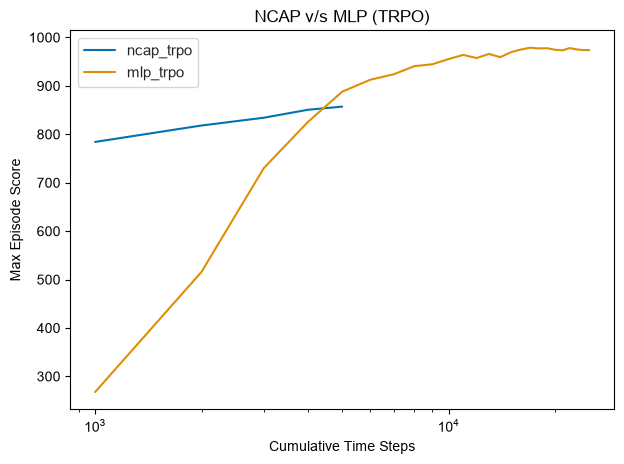

In [5]:
# rerun this cell if it displays more than the graphs
%matplotlib inline
fig, ax = plt.subplots()

# Learning curve of every network trained above, using the same parameters so the
# paths always match what the training cell wrote.
paths = [run_path(network, RL_METHOD, N_LINKS) for network in NETWORKS]
title = f'{" v/s ".join(n.upper() for n in NETWORKS)} ({RL_METHOD.upper()})'
plot_performance(paths, ax=ax, title=title)
plt.tight_layout()
plt.show()

In [6]:
play_model(run_path('mlp', RL_METHOD, N_LINKS))

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-swim/mlp_trpo\checkpoints\step_500000.pt
Reward for the run:  972.93506


In [7]:
play_model(run_path('ncap', RL_METHOD, N_LINKS))

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-swim/ncap_trpo\checkpoints\step_100000.pt
Reward for the run:  853.2404
